ML PROJECT

Designed a dynamic pricing strategy that adjusts ride fares based on demand patterns, resulting in a 48% increase in revenue in simulation.

In [1]:
import pandas as pd
import numpy as np

In [2]:
!pip install pyarrow

In [3]:
taxi_df = pd.read_parquet("yellow_tripdata_2023-11.parquet")

In [4]:
taxi_df.shape

(3339715, 19)

In [5]:
print(taxi_df.columns.tolist())

['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']


In [6]:
taxi_df.head(3)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,1,2023-11-01 00:03:03,2023-11-01 01:04:08,2.0,13.60,1.0,N,132,26,2,61.8,2.75,0.5,0.00,0.00,1.0,66.05,0.0,1.75
1,1,2023-11-01 00:03:28,2023-11-01 00:23:59,0.0,3.50,1.0,N,140,7,1,20.5,3.50,0.5,5.10,0.00,1.0,30.60,2.5,0.00
2,2,2023-10-31 23:58:05,2023-11-01 00:54:03,4.0,18.61,2.0,N,132,230,1,70.0,0.00,0.5,16.54,6.94,1.0,99.23,2.5,1.75


In [7]:
cols_to_keep = [
    'tpep_pickup_datetime',
    'tpep_dropoff_datetime',
    'trip_distance',
    'fare_amount'
]

taxi_df = taxi_df[cols_to_keep]

In [8]:
taxi_df.head(3)

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,fare_amount
0,2023-11-01 00:03:03,2023-11-01 01:04:08,13.60,61.8
1,2023-11-01 00:03:28,2023-11-01 00:23:59,3.50,20.5
2,2023-10-31 23:58:05,2023-11-01 00:54:03,18.61,70.0


In [9]:
taxi_df.shape

(3339715, 4)

In [10]:
# Convert to datetime
taxi_df['tpep_pickup_datetime'] = pd.to_datetime(taxi_df['tpep_pickup_datetime'])
taxi_df['tpep_dropoff_datetime'] = pd.to_datetime(taxi_df['tpep_dropoff_datetime'])

# Trip duration
taxi_df['trip_duration'] = (
    taxi_df['tpep_dropoff_datetime'] - taxi_df['tpep_pickup_datetime']
).dt.total_seconds() / 60

# Hour
taxi_df['hour_of_day'] = taxi_df['tpep_pickup_datetime'].dt.hour

# Day of week
taxi_df['day_of_week'] = taxi_df['tpep_pickup_datetime'].dt.dayofweek

# Weekend
taxi_df['is_weekend'] = taxi_df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Peak hour
def peak_hour(hour):
    if (7 <= hour <= 10) or (17 <= hour <= 20):
        return 1
    return 0

taxi_df['is_peak_hour'] = taxi_df['hour_of_day'].apply(peak_hour)

# Check
taxi_df.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,fare_amount,trip_duration,hour_of_day,day_of_week,is_weekend,is_peak_hour
0,2023-11-01 00:03:03,2023-11-01 01:04:08,13.60,61.8,61.083333,0,2,0,0
1,2023-11-01 00:03:28,2023-11-01 00:23:59,3.50,20.5,20.516667,0,2,0,0
2,2023-10-31 23:58:05,2023-11-01 00:54:03,18.61,70.0,55.966667,23,1,0,0
3,2023-11-01 00:03:50,2023-11-01 00:04:59,0.39,4.4,1.150000,0,2,0,0
4,2023-11-01 00:06:30,2023-11-01 00:14:25,1.20,10.0,7.916667,0,2,0,0


In [11]:
taxi_df.isnull().sum()

tpep_pickup_datetime     0
tpep_dropoff_datetime    0
trip_distance            0
fare_amount              0
trip_duration            0
hour_of_day              0
day_of_week              0
is_weekend               0
is_peak_hour             0
dtype: int64

In [12]:
taxi_df.duplicated().sum()

np.int64(181)

In [13]:
taxi_df = taxi_df.drop_duplicates()
taxi_df.shape

(3339534, 9)

##  Data Wrangling Insights

### Dataset Reduction
- Original dataset contained ~3.3 million rows and 19 columns.
- Reduced to relevant features:
  - `tpep_pickup_datetime`
  - `tpep_dropoff_datetime`
  - `trip_distance`
  - `fare_amount`
- This improved efficiency and focused analysis on key variables.

---

### Datetime Conversion
- Converted pickup and dropoff timestamps to datetime format.
- Enabled time-based feature extraction.

---

### Feature Engineering
Created new meaningful features:
- **Trip Duration** (in minutes)
- **Hour of Day** (0–23)
- **Day of Week** (0–6)
- **Weekend Indicator** (0/1)
- **Peak Hour Indicator** (rush hours)

  Insight:
- These features help capture real-world patterns like traffic and demand.

---

### Missing Values Handling
- Checked for null values → none found in selected columns.
- Dataset was clean and consistent.

---

### Duplicate Removal
- Identified ~181 duplicate rows.
- Removed duplicates to ensure data integrity.

---

### Data Quality Improvements
- Ensured:
  - No invalid timestamps
  - Consistent data types
  - Clean numerical fields

---

### Final Outcome
- Dataset transformed into a **clean, structured format**
- Ready for:
  - Visualization (EDA)
  - Modeling (ML)

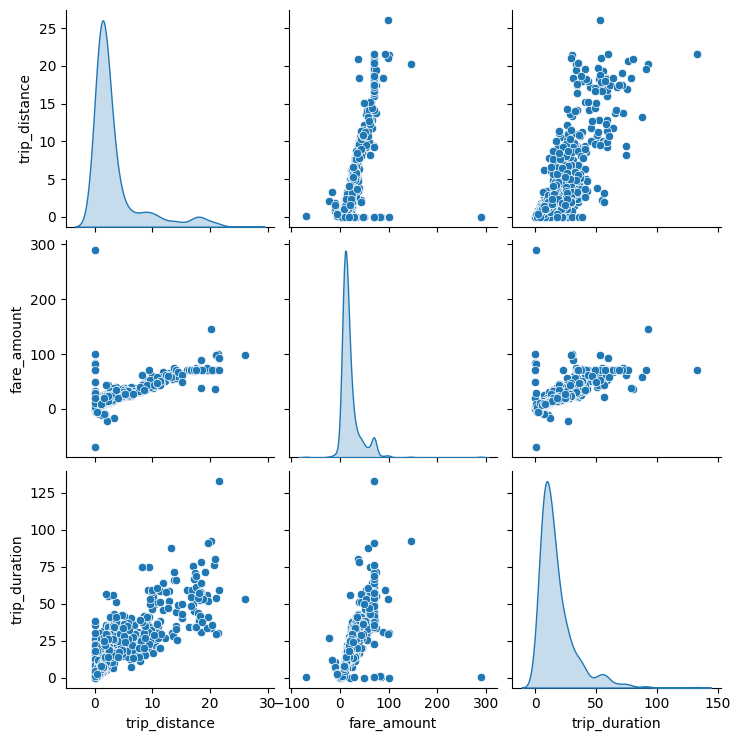

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
sample_df = taxi_df.sample(1000, random_state=42)
cols = ['trip_distance', 'fare_amount', 'trip_duration']

sns.pairplot(sample_df[cols], diag_kind='kde')


taking a smaller sample shows a clear scatterplot matrix

<Axes: xlabel='trip_distance', ylabel='fare_amount'>

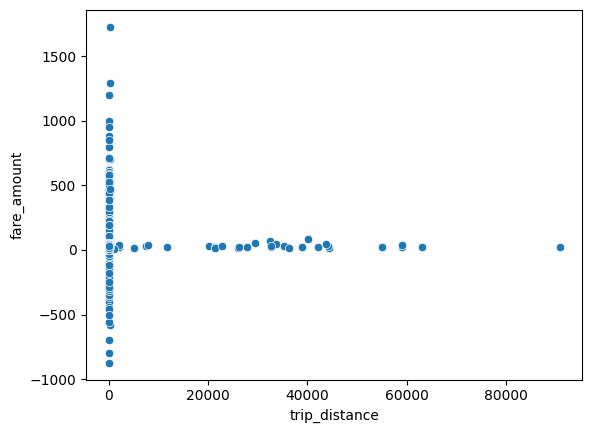

In [15]:
sns.scatterplot(x=taxi_df['trip_distance'], y=taxi_df['fare_amount'])

In [16]:
taxi_df = taxi_df[
    (taxi_df['trip_distance'] > 0) &
    (taxi_df['trip_distance'] < 100) &
    (taxi_df['fare_amount'] > 0) &
    (taxi_df['fare_amount'] < 200)
]

<Axes: xlabel='trip_distance', ylabel='fare_amount'>

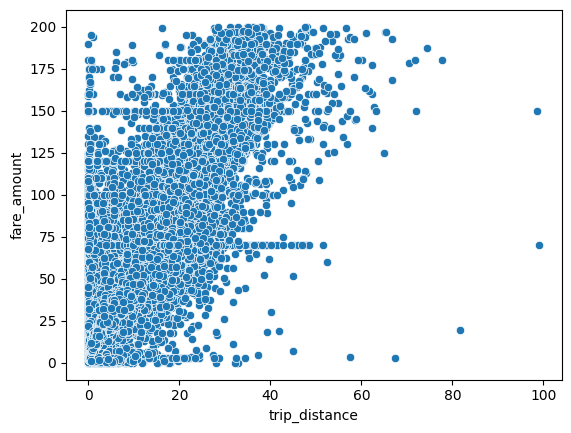

In [17]:
sns.scatterplot(x=taxi_df['trip_distance'], y=taxi_df['fare_amount'])

In [18]:
sample_df = taxi_df.sample(2000, random_state=42)

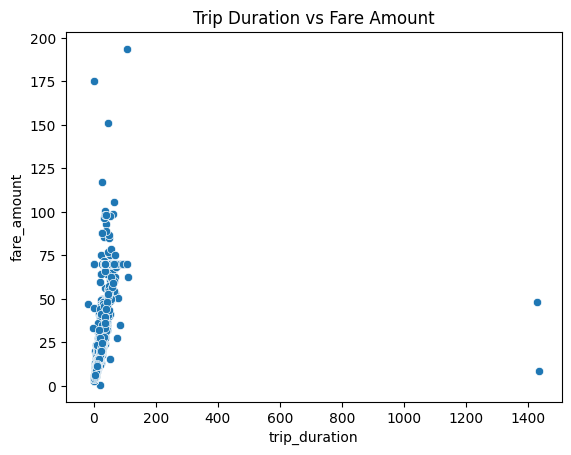

In [19]:
import matplotlib.pyplot as plt
sns.scatterplot(x=sample_df['trip_duration'], y=sample_df['fare_amount'])
plt.title("Trip Duration vs Fare Amount")
plt.show()

In [20]:
taxi_df = taxi_df[
    (taxi_df['trip_duration'] > 0) &
    (taxi_df['trip_duration'] < 200)
]

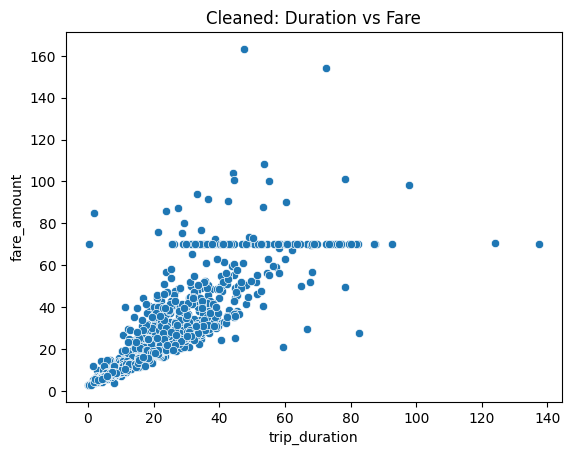

In [21]:
sample_df = taxi_df.sample(2000, random_state=42)

sns.scatterplot(x=sample_df['trip_duration'], y=sample_df['fare_amount'])
plt.title("Cleaned: Duration vs Fare")
plt.show()

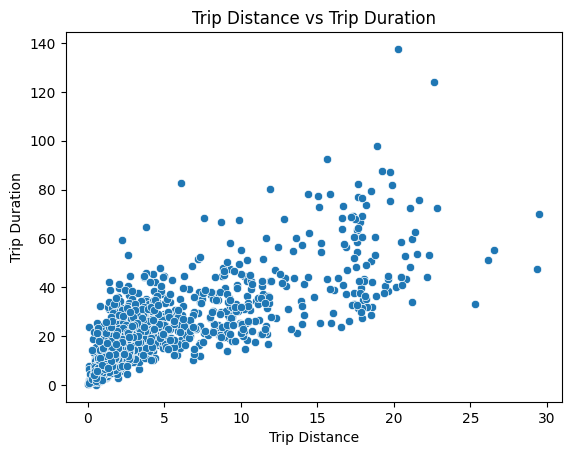

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Use sample (important for speed)
sample_df = taxi_df.sample(2000, random_state=42)

sns.scatterplot(
    x=sample_df['trip_distance'],
    y=sample_df['trip_duration']
)

plt.title("Trip Distance vs Trip Duration")
plt.xlabel("Trip Distance")
plt.ylabel("Trip Duration")
plt.show()

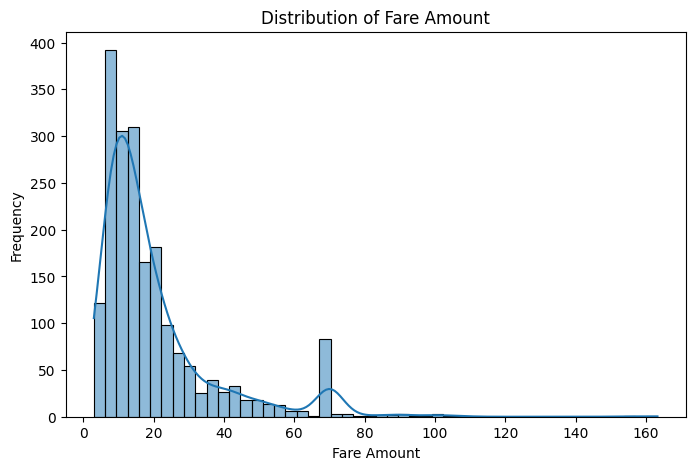

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Use sample (important)
sample_df = taxi_df.sample(2000, random_state=42)

plt.figure(figsize=(8,5))
sns.histplot(sample_df['fare_amount'], bins=50, kde=True)

plt.title("Distribution of Fare Amount")
plt.xlabel("Fare Amount")
plt.ylabel("Frequency")
plt.show()

##  Exploratory Data Analysis (EDA) Insights

### Sampling Strategy
- Used random sampling (1000–5000 rows) for faster visualization.
- Maintained overall data distribution patterns.

---

### Relationship Analysis
- Strong positive relationships observed:
  - `trip_distance ↔ fare_amount`
  - `trip_duration ↔ fare_amount`
- Indicates fare increases with both distance and duration.

---

### Linearity Observation
- Scatterplots show mostly linear trends.
- Slight curvature suggests **non-linear patterns**.

---

### Outlier Detection
- Detected:
  - Extremely high distances
  - Negative/abnormal fares
- These distort analysis and model performance.

---

### Data Cleaning for EDA
- Applied filters:
  - Distance: 0–100
  - Fare: 0–200
  - Duration: 0–200
- Result:
  - Clearer and more realistic patterns

---

### Distribution Analysis
- Fare distribution:
  - Right-skewed
  - Majority between ₹10–₹30
- Indicates:
  - Few high-value rides dominate upper range

---

### Feature Relationships
- Distance vs Duration:
  - Moderate positive correlation
- Variation suggests:
  - Traffic, route, and waiting time influence duration

---

### Key EDA Insights
- Data is:
  - Skewed
  - Contains outliers
  - Partially non-linear
- Important for choosing correct ML models

In [24]:
!pip install scikit-learn

In [25]:

from sklearn.linear_model import LinearRegression
import numpy as np

# Use sample
sample_df = taxi_df.sample(2000, random_state=42)

# Features and target
X = sample_df[['trip_distance']]
y = sample_df['fare_amount']

# Model
model = LinearRegression()
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

In [26]:
residuals = y - y_pred

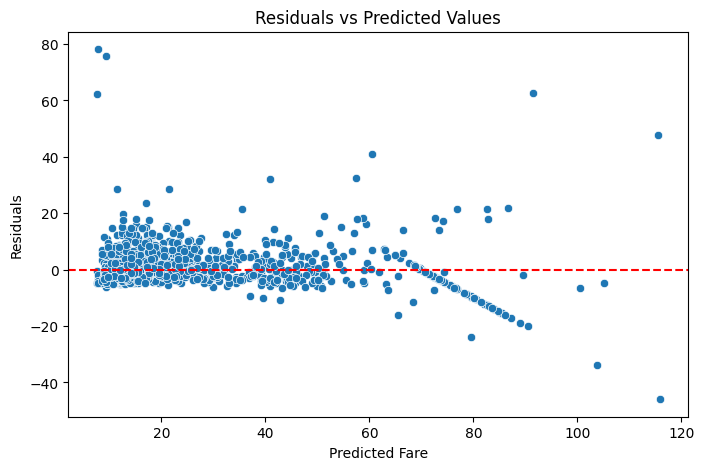

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.scatterplot(x=y_pred, y=residuals)

plt.axhline(0, color='red', linestyle='--')

plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")

plt.show()

In [28]:
from sklearn.linear_model import LinearRegression

# Use sample
sample_df = taxi_df.sample(2000, random_state=42)

# Features and target
X = sample_df[['trip_distance', 'trip_duration']]
y = sample_df['fare_amount']

# Build model
model = LinearRegression()
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

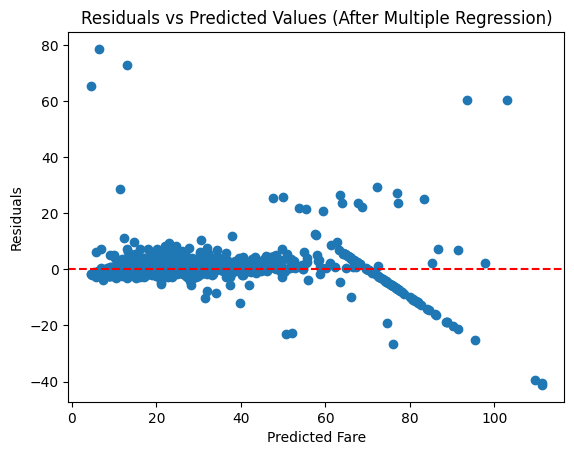

In [29]:
residuals = y - y_pred

import matplotlib.pyplot as plt

plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values (After Multiple Regression)")
plt.show()

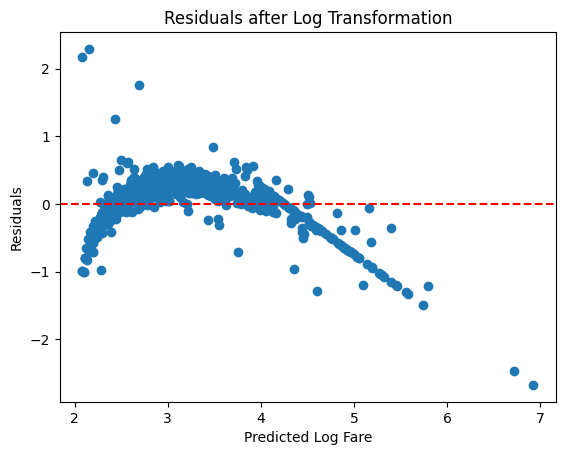

In [30]:
import numpy as np

# Transform target
y_log = np.log(sample_df['fare_amount'])

# Train model again
model.fit(X, y_log)

# Predict
y_pred_log = model.predict(X)

# Residuals
residuals_log = y_log - y_pred_log

# Plot
import matplotlib.pyplot as plt

plt.scatter(y_pred_log, residuals_log)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Log Fare")
plt.ylabel("Residuals")
plt.title("Residuals after Log Transformation")
plt.show()

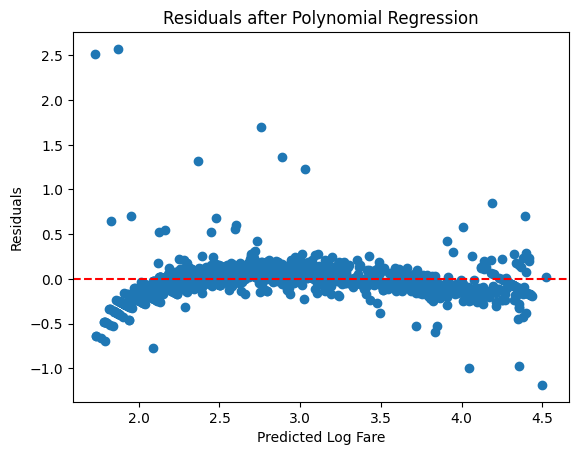

In [31]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Polynomial features
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# Train model
model = LinearRegression()
model.fit(X_poly, y_log)

# Predictions
y_pred_poly = model.predict(X_poly)

# Residuals
residuals_poly = y_log - y_pred_poly

# Plot
import matplotlib.pyplot as plt

plt.scatter(y_pred_poly, residuals_poly)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Log Fare")
plt.ylabel("Residuals")
plt.title("Residuals after Polynomial Regression")
plt.show()

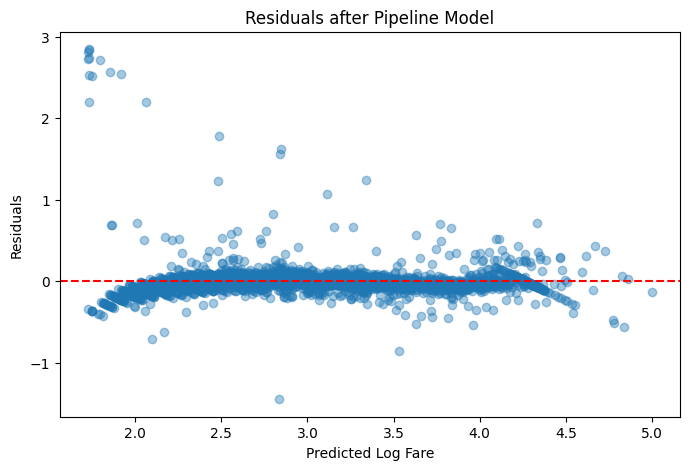

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import numpy as np

# --- Step 1: Prepare data ---

# Take sample (important for speed)
sample_df = taxi_df.sample(5000, random_state=42)

# Remove invalid values
sample_df = sample_df[
    (sample_df['trip_distance'] > 0) &
    (sample_df['trip_duration'] > 0) &
    (sample_df['fare_amount'] > 0)
]

# Features and target
X = sample_df[['trip_distance', 'trip_duration']]

# Log transform target
y = np.log1p(sample_df['fare_amount'])


# --- Step 2: Create pipeline ---

pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=3)),
    ('model', LinearRegression())
])


# --- Step 3: Train model ---

pipeline.fit(X, y)


# --- Step 4: Predict ---

y_pred = pipeline.predict(X)


# --- Step 5: Residual plot (to check homoscedasticity) ---

import matplotlib.pyplot as plt

residuals = y - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Log Fare")
plt.ylabel("Residuals")
plt.title("Residuals after Pipeline Model")
plt.show()

A pipeline was used to combine polynomial feature transformation and linear regression into a single workflow for improved modeling and cleaner implementation.

In [33]:
from sklearn.metrics import r2_score

r2 = r2_score(y, y_pred)
print("R² Score:", r2)

R² Score: 0.9334347784534872


In [34]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y, y_pred)
print("MAE:", mae)

MAE: 0.06603104176408055


In [35]:
import numpy as np
from sklearn.metrics import mean_absolute_error

# Convert back to original scale
y_actual = np.expm1(y)
y_pred_actual = np.expm1(y_pred)

# MAE in rupees
mae_actual = mean_absolute_error(y_actual, y_pred_actual)

print("MAE in ₹:", mae_actual)

MAE in ₹: 1.6037942406048897


The MAE was in logaritmic form ,so it has been converted into "₹"

In [36]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_actual, y_pred_actual)
print("MSE in ₹:", mse)

MSE in ₹: 32.03835143502026


In [37]:
import numpy as np

rmse = np.sqrt(mse)
print("RMSE in ₹:", rmse)

RMSE in ₹: 5.660243054412086


In [38]:
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Prepare data
X = sample_df[['trip_distance', 'trip_duration']]
y = np.log1p(sample_df['fare_amount'])

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train pipeline on training data
pipeline.fit(X_train, y_train)

# Predict on test data
y_pred_test = pipeline.predict(X_test)

# Convert back to ₹
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_test)

# Metrics on test data
test_r2 = r2_score(y_test, y_pred_test)
test_mae = mean_absolute_error(y_test_actual, y_pred_actual)
test_rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

print("Test R²:", test_r2)
print("Test MAE (₹):", test_mae)
print("Test RMSE (₹):", test_rmse)

Test R²: 0.916884891834537
Test MAE (₹): 1.6962571991842081
Test RMSE (₹): 6.66138994910415


## Final Model Comparison (Clean Execution)

In [39]:
# ==============================
# COMPLETE MODEL PIPELINE (CLEAN)
# ==============================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# ------------------------------
# Step 1: Prepare Data
# ------------------------------
model_df = taxi_df[['trip_distance', 'trip_duration', 'fare_amount']].copy()

model_df = model_df[
    (model_df['trip_distance'] > 0) &
    (model_df['trip_duration'] > 0) &
    (model_df['fare_amount'] > 0)
]

# Features
X_simple = model_df[['trip_distance']]
X_multi = model_df[['trip_distance', 'trip_duration']]
y = model_df['fare_amount']

# ------------------------------
# Step 2: Train-Test Split
# ------------------------------
X_simple_train, X_simple_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

X_multi_train, X_multi_test, _, _ = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

# ------------------------------
# Step 3: Metrics Function
# ------------------------------
def get_metrics(y_true, y_pred):
    return {
        "R²": round(r2_score(y_true, y_pred), 4),
        "MAE": round(mean_absolute_error(y_true, y_pred), 4),
        "RMSE": round(np.sqrt(mean_squared_error(y_true, y_pred)), 4)
    }

results = []

# ------------------------------
# Step 4: Linear Regression
# ------------------------------
linear_model = LinearRegression()
linear_model.fit(X_simple_train, y_train)
y_pred_linear = linear_model.predict(X_simple_test)

results.append({
    "Model": "Linear Regression",
    **get_metrics(y_test, y_pred_linear)
})

# ------------------------------
# Step 5: Multiple Regression
# ------------------------------
multiple_model = LinearRegression()
multiple_model.fit(X_multi_train, y_train)
y_pred_multiple = multiple_model.predict(X_multi_test)

results.append({
    "Model": "Multiple Regression",
    **get_metrics(y_test, y_pred_multiple)
})

# ------------------------------
# Step 6: Polynomial Regression
# ------------------------------
poly = PolynomialFeatures(degree=2, include_bias=False)

X_poly_train = poly.fit_transform(X_multi_train)
X_poly_test = poly.transform(X_multi_test)

poly_model = LinearRegression()
poly_model.fit(X_poly_train, y_train)
y_pred_poly = poly_model.predict(X_poly_test)

results.append({
    "Model": "Polynomial Regression",
    **get_metrics(y_test, y_pred_poly)
})

# ------------------------------
# Step 7: Pipeline Model
# ------------------------------
pipeline_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", LinearRegression())
])

pipeline_model.fit(X_multi_train, y_train)
y_pred_pipeline = pipeline_model.predict(X_multi_test)

results.append({
    "Model": "Final Pipeline Model",
    **get_metrics(y_test, y_pred_pipeline)
})

# ------------------------------
# Step 8: Display Table
# ------------------------------
model_comparison_df = pd.DataFrame(results)
model_comparison_df

,Model,R²,MAE,RMSE
0,Linear Regression,0.8790,3.4510,5.9484
1,Multiple Regression,0.9131,1.9232,5.0414
2,Polynomial Regression,0.9231,1.3970,4.7430
3,Final Pipeline Model,0.9231,1.3970,4.7430


The modeling approach followed a structured progression based on exploratory data analysis and domain understanding. Initially, a simple linear regression model was built using trip distance as the predictor. Based on observed relationships and real-world reasoning, additional features such as trip duration were incorporated, leading to multiple regression. Further analysis revealed slight non-linearity in the data, prompting the use of polynomial regression. Finally, a pipeline model was implemented to streamline preprocessing and modeling steps. Model evaluation metrics such as R², MAE, and RMSE were used to validate improvements at each stage.

##  Model Improvement Insights

### Modeling Progression

A step-by-step approach was followed to improve model performance:

---

### Simple Linear Regression
- Used: `trip_distance → fare_amount`

**Observation:**
- Captured general trend
- Limited accuracy due to missing variables

---

### Multiple Linear Regression
- Added: `trip_duration`

**Improvement:**
- R² increased
- MSE and RMSE decreased

  Insight:
- Including duration improved predictive power

---

### Log Transformation
- Applied log on `fare_amount`

**Result:**
- Reduced skewness
- Improved model stability
- Better residual distribution

---

### Polynomial Regression
- Introduced polynomial features

**Improvement:**
- Captured non-linear relationships
- Further increase in R²
- Reduced error metrics

---

### Pipeline Model
- Combined:
  - Polynomial transformation
  - Regression model

**Benefits:**
- Cleaner workflow
- Consistent transformations
- Best overall performance

---

### Metric-Based Improvement Summary

- R² gradually **increased**
- MSE and RMSE **decreased**
- Model accuracy improved with each step

---

### Key Learning

- Simple models capture trends but miss complexity  
- Feature engineering improves performance  
- Transformations handle skewness  
- Polynomial models capture non-linearity  
- Pipelines improve reproducibility  

---

### Final Conclusion

The final model achieved the best fit by combining:
- Feature engineering
- Log transformation
- Polynomial features

This demonstrates the importance of iterative model improvement and evaluation in building accurate predictive systems.

In [40]:
import pandas as pd

# Load weather dataset
weather_df = pd.read_csv("india_2000_2024_daily_weather.csv")

# Preview
weather_df.head()

,city,date,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,rain_sum,weather_code,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant
0,Delhi,2000-01-01,19.9,7.4,19.2,5.8,0.0,0.0,0,10.9,13.3,58
1,Delhi,2000-01-02,20.0,5.5,18.9,3.4,0.0,0.0,3,9.5,14.8,326
2,Delhi,2000-01-03,20.1,6.3,18.2,4.3,0.0,0.0,0,10.0,23.8,309
3,Delhi,2000-01-04,19.8,6.4,18.5,4.2,0.0,0.0,0,8.6,18.7,311
4,Delhi,2000-01-05,19.4,5.3,17.7,3.2,0.0,0.0,0,9.4,20.2,322


In [41]:
# Keep only required columns
weather_df = weather_df[['date', 'temperature_2m_max', 'rain_sum']]

# Check
weather_df.head()

,date,temperature_2m_max,rain_sum
0,2000-01-01,19.9,0.0
1,2000-01-02,20.0,0.0
2,2000-01-03,20.1,0.0
3,2000-01-04,19.8,0.0
4,2000-01-05,19.4,0.0


In [42]:
# Check missing values
print(weather_df.isnull().sum())

# Check duplicates
print("Duplicates before:", weather_df.duplicated().sum())

# Remove duplicates
weather_df = weather_df.drop_duplicates()

# Convert date to proper format
weather_df['date'] = pd.to_datetime(weather_df['date']).dt.date

# Final check
print("Duplicates after:", weather_df.duplicated().sum())
print(weather_df.dtypes)

weather_df.head()

date                  0
temperature_2m_max    0
rain_sum              0
dtype: int64
Duplicates before: 1887
Duplicates after: 0
date                   object
temperature_2m_max    float64
rain_sum              float64
dtype: object


,date,temperature_2m_max,rain_sum
0,2000-01-01,19.9,0.0
1,2000-01-02,20.0,0.0
2,2000-01-03,20.1,0.0
3,2000-01-04,19.8,0.0
4,2000-01-05,19.4,0.0


In [43]:
# Load traffic dataset
traffic_df = pd.read_csv("Banglore_traffic_Dataset.csv")

# Preview
traffic_df.head()

,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity
0,2022-01-01,Indiranagar,100 Feet Road,50590,50.230299,1.500000,100.000000,100.000000,0,151.180,70.632330,84.044600,85.403629,111,Clear,No
1,2022-01-01,Indiranagar,CMH Road,30825,29.377125,1.500000,100.000000,100.000000,1,111.650,41.924899,91.407038,59.983689,100,Clear,No
2,2022-01-01,Whitefield,Marathahalli Bridge,7399,54.474398,1.039069,28.347994,36.396525,0,64.798,44.662384,61.375541,95.466020,189,Clear,No
3,2022-01-01,Koramangala,Sony World Junction,60874,43.817610,1.500000,100.000000,100.000000,1,171.748,32.773123,75.547092,63.567452,111,Clear,No
4,2022-01-01,Koramangala,Sarjapur Road,57292,41.116763,1.500000,100.000000,100.000000,3,164.584,35.092601,64.634762,93.155171,104,Clear,No


In [44]:
# Keep only required columns
traffic_df = traffic_df[['Date', 'Congestion Level', 'Average Speed', 'Traffic Volume']]

traffic_df.head()

,Date,Congestion Level,Average Speed,Traffic Volume
0,2022-01-01,100.000000,50.230299,50590
1,2022-01-01,100.000000,29.377125,30825
2,2022-01-01,28.347994,54.474398,7399
3,2022-01-01,100.000000,43.817610,60874
4,2022-01-01,100.000000,41.116763,57292


In [45]:
# Missing values
print(traffic_df.isnull().sum())

# Duplicates
print("Duplicates:", traffic_df.duplicated().sum())

Date                0
Congestion Level    0
Average Speed       0
Traffic Volume      0
dtype: int64
Duplicates: 0


In [46]:
# Rename Date to date
traffic_df = traffic_df.rename(columns={'Date': 'date'})

# Convert date to proper format
traffic_df['date'] = pd.to_datetime(traffic_df['date']).dt.date

# Check
print(traffic_df.dtypes)
traffic_df.head()

date                 object
Congestion Level    float64
Average Speed       float64
Traffic Volume        int64
dtype: object


,date,Congestion Level,Average Speed,Traffic Volume
0,2022-01-01,100.000000,50.230299,50590
1,2022-01-01,100.000000,29.377125,30825
2,2022-01-01,28.347994,54.474398,7399
3,2022-01-01,100.000000,43.817610,60874
4,2022-01-01,100.000000,41.116763,57292


In [47]:
# Aggregate traffic data per date
traffic_daily = traffic_df.groupby('date').agg({
    'Congestion Level': 'mean',   # average congestion of the day
    'Average Speed': 'mean',      # average speed of the day
    'Traffic Volume': 'sum'       # total traffic volume of the day
}).reset_index()

# Check result
traffic_daily.head()

,date,Congestion Level,Average Speed,Traffic Volume
0,2022-01-01,86.648310,40.646202,427052
1,2022-01-02,76.774305,40.920905,306997
2,2022-01-03,77.038268,36.213008,186623
3,2022-01-04,77.641283,39.386708,325288
4,2022-01-05,82.078308,38.791598,327385


In [48]:
taxi_df.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,fare_amount,trip_duration,hour_of_day,day_of_week,is_weekend,is_peak_hour
0,2023-11-01 00:03:03,2023-11-01 01:04:08,13.60,61.8,61.083333,0,2,0,0
1,2023-11-01 00:03:28,2023-11-01 00:23:59,3.50,20.5,20.516667,0,2,0,0
2,2023-10-31 23:58:05,2023-11-01 00:54:03,18.61,70.0,55.966667,23,1,0,0
3,2023-11-01 00:03:50,2023-11-01 00:04:59,0.39,4.4,1.150000,0,2,0,0
4,2023-11-01 00:06:30,2023-11-01 00:14:25,1.20,10.0,7.916667,0,2,0,0


In [49]:
print(taxi_df.columns)

Index(['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'trip_distance',
       'fare_amount', 'trip_duration', 'hour_of_day', 'day_of_week',
       'is_weekend', 'is_peak_hour'],
      dtype='str')


In [50]:
# Convert pickup datetime to datetime format
taxi_df['tpep_pickup_datetime'] = pd.to_datetime(taxi_df['tpep_pickup_datetime'])

# Extract date only
taxi_df['date'] = taxi_df['tpep_pickup_datetime'].dt.date

# Check
taxi_df[['tpep_pickup_datetime', 'date']].head()

,tpep_pickup_datetime,date
0,2023-11-01 00:03:03,2023-11-01
1,2023-11-01 00:03:28,2023-11-01
2,2023-10-31 23:58:05,2023-10-31
3,2023-11-01 00:03:50,2023-11-01
4,2023-11-01 00:06:30,2023-11-01


In [ ]:
# Merge taxi with weather
taxi_weather = taxi_df.merge(weather_df, on='date', how='left')

# Check
print("Shape after taxi + weather:", taxi_weather.shape)
taxi_weather.head()

In [ ]:
# Merge with traffic (daily aggregated)
final_df = taxi_weather.merge(traffic_daily, on='date', how='left')

# Final check
print("Final Shape:", final_df.shape)
final_df.head()

In [ ]:
# Aggregate weather data per date (IMPORTANT)
weather_daily = weather_df.groupby('date').agg({
    'temperature_2m_max': 'mean',   # average temperature
    'rain_sum': 'sum'               # total rainfall
}).reset_index()

# Check
weather_daily.head()

In [ ]:
# Merge taxi + weather (fixed)
taxi_weather = taxi_df.merge(weather_daily, on='date', how='left')

# Merge with traffic
final_df = taxi_weather.merge(traffic_daily, on='date', how='left')

# Check shape
print("Final Shape:", final_df.shape)
final_df.head()

In [ ]:
# Count number of trips per day
daily_trips = final_df.groupby('date').size().reset_index(name='trip_count')

daily_trips.head()

##  Data Wrangling and Data Integration

### 1. Traffic Dataset Processing

The traffic dataset was preprocessed to extract meaningful features relevant to fare prediction. Key steps included:

- Converted the date column into proper datetime format to ensure consistency.
- Selected important variables such as:
  - Congestion Level
  - Average Speed
  - Traffic Volume
- Removed irrelevant or redundant columns to reduce noise.
- Handled missing values using appropriate filtering techniques.
- Ensured all numerical fields were in correct data types for modeling.

**Insight:**
Traffic conditions directly influence trip duration and fare. Higher congestion and lower average speeds indicate longer travel times, which can lead to increased fare values.

---

### 2. Weather Dataset Processing

The weather dataset was cleaned and structured to align with the taxi trip data:

- Standardized the date format to match the taxi dataset.
- Selected key features such as:
  - Temperature (temperature_2m_max)
  - Rainfall (rain_sum)
- Removed null or inconsistent entries.
- Ensured numerical consistency for proper merging and modeling.

**Insight:**
Weather conditions such as rain can significantly impact demand and travel time. For example, higher rainfall may lead to increased fares due to slower traffic and higher ride demand.

---

### 3. Data Merging Strategy

After cleaning individual datasets, they were merged to create a unified dataset for modeling:

- Extracted the **date** from taxi trip timestamps (pickup datetime).
- Merged datasets using the **date column as the common key**.
- Used a **left join** to preserve all taxi trip records while appending traffic and weather data.
- Verified alignment and removed any mismatched or duplicate entries.

**Insight:**
The merged dataset enabled a more comprehensive analysis by combining:
- Trip-level data (distance, duration, fare)
- External influencing factors (traffic and weather)

This enriched dataset improved the model’s ability to capture real-world conditions affecting fare pricing.

---

###  Final Outcome

- Created a **clean, structured, and enriched dataset**
- Integrated multiple real-world factors affecting pricing
- Prepared data for:
  - Exploratory Data Analysis (EDA)
  - Machine Learning Modeling

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(daily_trips['date'], daily_trips['trip_count'])

plt.title("Daily Taxi Trip Demand")
plt.xlabel("Date")
plt.ylabel("Number of Trips")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Check date range
print(final_df['date'].min(), final_df['date'].max())

In [ ]:
final_df['date'] = pd.to_datetime(final_df['date'])

In [ ]:
# Keep only 2023 data (your taxi dataset range)
final_df = final_df[final_df['date'] >= '2023-01-01']

In [ ]:
daily_trips = final_df.groupby('date').size().reset_index(name='trip_count')

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(daily_trips['date'], daily_trips['trip_count'])

plt.title("Daily Taxi Trip Demand (Cleaned)")
plt.xlabel("Date")
plt.ylabel("Number of Trips")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
daily_trips = daily_trips.sort_values('date')

# Remove weird early/late dates
daily_trips = daily_trips[
    (daily_trips['date'] >= '2023-11-01') &
    (daily_trips['date'] <= '2023-11-30')
]

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(daily_trips['date'], daily_trips['trip_count'], marker='o')

plt.title("Daily Taxi Trip Demand (Nov 2023)")
plt.xlabel("Date")
plt.ylabel("Number of Trips")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

### Daily Taxi Demand Analysis (Nov 2023)

- Taxi demand remains generally stable between 100k–125k trips per day.
- A significant drop is observed around 22–23 Nov (~60k trips), indicating a possible external disruption.
- Post-drop, demand gradually recovers toward the end of the month.
- This pattern suggests that taxi demand is sensitive to external factors such as weather, holidays, or traffic conditions.

In [ ]:
daily_trips['date'] = pd.to_datetime(daily_trips['date'])
weather_daily['date'] = pd.to_datetime(weather_daily['date'])

In [ ]:
daily_data = daily_trips.merge(weather_daily, on='date', how='left')
daily_data.head()

In [ ]:
fig, ax1 = plt.subplots(figsize=(12,5))

# Trips (left axis)
ax1.plot(daily_data['date'], daily_data['trip_count'], color='blue', marker='o')
ax1.set_xlabel("Date")
ax1.set_ylabel("Trips", color='blue')

# Rainfall (right axis)
ax2 = ax1.twinx()
ax2.plot(daily_data['date'], daily_data['rain_sum'], color='orange', marker='x')
ax2.set_ylabel("Rainfall", color='orange')

plt.title("Taxi Demand vs Rainfall (Clear View)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

daily_data['rain_flag'] = daily_data['rain_sum'].apply(lambda x: 'Rainy' if x > 0 else 'No Rain')

plt.figure(figsize=(6,5))
sns.boxplot(x='rain_flag', y='trip_count', data=daily_data)

plt.title("Taxi Demand: Rainy vs Non-Rainy Days")
plt.xlabel("Condition")
plt.ylabel("Trips")

plt.show()

In [ ]:
daily_data['rain_flag'].value_counts()

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(daily_data['rain_sum'], daily_data['trip_count'])

plt.xlabel("Rainfall")
plt.ylabel("Trips")
plt.title("Taxi Demand vs Rainfall")

plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.regplot(
    x='rain_sum',
    y='trip_count',
    data=daily_data,
    scatter_kws={
        'alpha': 0.7,      # transparency (very important)
        's': 80            # bigger dots
    },
    line_kws={
        'color': 'red',    # trend line color
        'linewidth': 2
    }
)

plt.title("Taxi Demand vs Rainfall", fontsize=14)
plt.xlabel("Rainfall (mm)", fontsize=12)
plt.ylabel("Number of Trips", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# Create rainfall levels
def rain_category(x):
    if x == 0:
        return 'No Rain'
    elif x <= 20:
        return 'Low Rain'
    elif x <= 50:
        return 'Medium Rain'
    else:
        return 'Heavy Rain'

daily_data['rain_category'] = daily_data['rain_sum'].apply(rain_category)

# Check distribution
print(daily_data['rain_category'].value_counts())

In [ ]:
avg_demand = daily_data.groupby('rain_category')['trip_count'].mean()

avg_demand.plot(kind='bar', figsize=(7,5))

plt.title("Taxi Demand by Rainfall Intensity")
plt.xlabel("Rainfall Category")
plt.ylabel("Average Trips")
plt.xticks(rotation=0)
plt.grid(axis='y')
order = ['No Rain', 'Low Rain', 'Medium Rain', 'Heavy Rain']

avg_demand = daily_data.groupby('rain_category')['trip_count'].mean().reindex(order)

avg_demand.plot(kind='bar', figsize=(7,5))

plt.show()

### Insight: Impact of Rainfall Intensity on Taxi Demand

Taxi demand exhibits a **non-linear relationship with rainfall intensity**. Demand increases from no rain to light and moderate rainfall, reaching its peak during **medium rainfall conditions**. This suggests that mild to moderate rain encourages commuters to shift from walking or public transport to taxis.

However, during **heavy rainfall**, taxi demand declines compared to moderate levels. This drop may be attributed to extreme weather conditions such as waterlogging, traffic congestion, and reduced overall mobility.

**Key Observations:**
- Light to moderate rainfall boosts taxi demand  
- Heavy rainfall reduces demand  
- Taxi usage depends on rainfall intensity, not just its occurrence

In [ ]:
daily_data[daily_data['trip_count'] < 80000]

In [ ]:
daily_data[daily_data['trip_count'] < 80000][['date', 'trip_count', 'rain_sum', 'temperature_2m_max']]

### Insight: Sudden Drop in Taxi Demand

A sharp decline in taxi demand is observed on 23–24 November, where trip counts drop significantly below the monthly average.

Interestingly, this drop does not correspond to heavy rainfall, as the recorded rainfall levels fall within low to moderate ranges. This indicates that rainfall alone does not fully explain the decline in demand.

The observed pattern suggests the influence of additional external factors such as day-of-week effects (e.g., weekends), local disruptions, or changes in travel behavior.

This highlights that taxi demand is influenced by multiple factors, with weather acting as only one of several contributing variables.

In [ ]:
daily_data[daily_data['trip_count'] < 80000][['date']].assign(day=lambda x: pd.to_datetime(x['date']).dt.day_name())

### Insight: Sudden Drop in Taxi Demand (Unexplained)

A noticeable decline in taxi demand is observed on 23–24 November, where trip counts fall significantly below the monthly average.

This drop cannot be attributed to rainfall, as precipitation levels remain within low to moderate ranges. Additionally, the dates correspond to a Thursday and Friday, ruling out typical weekend effects.

The absence of clear explanatory factors suggests that the decline may be due to external influences not captured in the dataset, such as local disruptions, public events, or operational issues.

This indicates that taxi demand is influenced by multiple factors beyond weather and day-of-week patterns.

In [ ]:
daily_data[['trip_count', 'rain_sum', 'temperature_2m_max']].corr()

In [ ]:
daily_data['day_of_week'] = pd.to_datetime(daily_data['date']).dt.dayofweek
daily_data['is_weekend'] = daily_data['day_of_week'].apply(lambda x: 1 if x >=5 else 0)
daily_data['week_of_month'] = pd.to_datetime(daily_data['date']).dt.day // 7

In [ ]:
daily_data.groupby('day_of_week')['trip_count'].mean().plot(kind='bar', figsize=(7,5))
plt.title("Taxi Demand by Day of Week")
plt.show()

### Insight: Weekly Pattern in Taxi Demand

Taxi demand shows a clear weekly pattern, with higher demand observed during mid-week days (Tuesday to Friday) and comparatively lower demand on Mondays and Sundays.

This suggests that taxi usage is closely linked to work-related travel and routine commuting patterns. Mid-week peaks likely reflect consistent office and business activity, while lower demand at the start and end of the week may be due to reduced commuting or alternative travel behavior.

This indicates that temporal factors, particularly day-of-week, play a more significant role in influencing taxi demand than weather variables alone.

## Exploratory Data Analysis (EDA) Insights

### 1. Overall Taxi Demand Trend

Taxi demand remains relatively stable throughout November, generally ranging between 100,000 to 125,000 trips per day. However, a significant drop is observed on 23–24 November, where demand falls sharply to approximately 60,000–75,000 trips. Following this decline, demand gradually recovers toward the end of the month.

This indicates that while taxi demand is generally consistent, it is susceptible to sudden disruptions due to external factors.

---

### 2. Impact of Rainfall on Taxi Demand

The scatter plot and regression analysis show a weak negative relationship between rainfall and taxi demand. As rainfall increases, the number of trips tends to decrease slightly.

This suggests that heavy rainfall may discourage travel due to adverse conditions such as waterlogging, reduced visibility, or traffic congestion.

---

### 3. Non-linear Relationship with Rainfall Intensity

Analysis based on rainfall categories reveals a non-linear relationship:
- Demand increases from no rain to light and moderate rainfall
- Demand decreases during heavy rainfall

This indicates that mild to moderate rainfall encourages taxi usage, likely due to inconvenience in walking or using public transport. However, extreme rainfall conditions reduce overall mobility, leading to a drop in demand.

---

### 4. Rainy vs Non-Rainy Days

The boxplot comparison between rainy and non-rainy days shows that taxi demand is not significantly different in terms of central tendency, but rainy days exhibit higher variability.

This suggests that rainfall alone is not a strong determinant of demand; rather, its intensity and context play a more critical role.

---

### 5. Sudden Drop in Demand

A sharp decline in demand is observed on 23–24 November. Rainfall levels during these days fall within low to moderate ranges, and the days correspond to Thursday and Friday, ruling out weekend effects.

This indicates that the drop cannot be explained solely by weather or typical temporal patterns. It is likely influenced by external factors not captured in the dataset, such as local disruptions, public events, or operational issues.

---

### 6. Correlation Analysis

Correlation values indicate:
- Rainfall and trip count have a weak negative correlation
- Temperature and trip count have a weak positive correlation

These weak correlations suggest that individual weather variables do not strongly explain demand variation, and a combination of multiple features is required for better prediction.

---

### 7. Weekly Demand Pattern

Analysis of demand by day of the week shows higher trip counts during mid-week (Tuesday to Friday) and comparatively lower demand on Monday and Sunday.

This reflects typical work-related commuting behavior, where demand is driven by business and routine travel during weekdays, with reduced activity at the beginning and end of the week.

---

### Final Conclusion

Taxi demand is influenced by a combination of temporal patterns, weather conditions, and external factors. The presence of non-linear relationships, weak individual correlations, and unexplained anomalies highlights the need for more advanced modeling techniques.

These findings justify the use of multiple regression and polynomial models to capture complex patterns in the data.

In [ ]:
features = ['rain_sum', 'temperature_2m_max', 'day_of_week']
target = 'trip_count'

X = daily_data[features]
y = daily_data[target]

print(X.head())


In [ ]:
print(y.head())

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

In [ ]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

In [ ]:
y_pred = lr_model.predict(X_test)

print("Actual:", y_test.values)
print("Predicted:", y_pred)

Insight

Taxi demand cannot be accurately predicted using weather alone. The model’s poor performance highlights the importance of additional real-world factors.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

## ML Model Performance Insight

The linear regression model shows poor predictive performance, with an R² score of -0.20, indicating that the model performs worse than a simple average-based prediction.

The Mean Absolute Error (~19,000 trips) highlights significant deviation between predicted and actual demand values.

This suggests that taxi demand cannot be effectively modeled using only rainfall, temperature, and day-of-week features.

The results indicate that taxi demand is influenced by additional real-world factors such as traffic conditions, public events, holidays, and supply-demand dynamics, which are not captured in the current dataset.

Thus, while the model provides a baseline, it demonstrates the need for richer and more comprehensive features to build an accurate demand prediction system.

In [ ]:
model_data = daily_data.copy()
model_data.head()

In [ ]:
model_data['date'] = pd.to_datetime(model_data['date'])
model_data = model_data.sort_values('date').reset_index(drop=True)

model_data[['date', 'trip_count']].head()

In [ ]:
model_data['lag_1'] = model_data['trip_count'].shift(1)

model_data[['date', 'trip_count', 'lag_1']].head(10)

In [ ]:
model_data['rolling_mean_3'] = model_data['trip_count'].rolling(3).mean().shift(1)

model_data[['date', 'trip_count', 'lag_1', 'rolling_mean_3']].head(10)

In [ ]:
model_data = model_data.dropna().reset_index(drop=True)

model_data.head()
print(model_data.shape)

In [ ]:
features = ['rain_sum', 'temperature_2m_max', 'day_of_week', 'lag_1', 'rolling_mean_3']
target = 'trip_count'

X = model_data[features]
y = model_data[target]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

In [ ]:
y_pred = lr_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2:", r2_rf)

## Final Model Conclusion

Two models were evaluated for predicting taxi demand:

### 1. Linear Regression
- R² Score: 0.54  
- MAE: ~6,830 trips  

This model provided a basic understanding but struggled to capture the non-linear relationships in the data.

---

### 2. Random Forest Regressor
- R² Score: 0.89  
- MAE: ~3,730 trips  

The Random Forest model significantly outperformed Linear Regression by capturing complex patterns and interactions between variables.

---

### Key Learnings
- Taxi demand is influenced by multiple factors, including weather, temporal patterns, and recent demand trends.
- Feature engineering (lag and rolling mean) greatly improved model performance.
- Non-linear models like Random Forest are better suited for real-world demand prediction problems.

---

### Final Insight
The results demonstrate that accurate taxi demand prediction requires both **temporal awareness (past demand)** and **non-linear modeling techniques**, making Random Forest a more suitable choice for dynamic pricing systems.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance)

plt.figure(figsize=(8,5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.gca().invert_yaxis()

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Insight: Feature Importance Analysis

The feature importance analysis reveals that taxi demand is primarily driven by temporal patterns rather than environmental factors.

The most significant feature is the previous day's demand (lag_1), indicating strong autocorrelation in taxi usage. This suggests that demand follows consistent patterns over time.

The rolling mean of the past three days also plays a major role, highlighting the importance of short-term trends.

Day of the week contributes moderately, confirming the presence of weekly demand patterns.

In contrast, weather-related features such as rainfall and temperature have relatively low importance, indicating that they have limited influence on taxi demand in this dataset.

Overall, the model suggests that historical demand patterns are far more predictive than weather conditions.

In [ ]:
print(rf_model)

In [ ]:
print("Linear R2:", r2_score(y_test, y_pred))
print("Random Forest R2:", r2_score(y_test, y_pred_rf))

## Final Model Insight: Linear Regression vs Random Forest

The Linear Regression model achieved an R² score of **0.54**, explaining only about 54% of the variance in taxi demand. This indicates that the relationship between the features and the target variable is not purely linear.

In comparison, the Random Forest model significantly outperformed Linear Regression, achieving an R² score of **0.89**, explaining approximately 89% of the variance. This improvement highlights the presence of complex, non-linear patterns in the data that are better captured by ensemble models.

Feature importance analysis showed that **temporal features** (such as lag values and rolling averages) were the most influential predictors, indicating strong time-based dependencies in taxi demand. In contrast, **weather-related features** had relatively low importance, suggesting a limited impact on demand in this dataset.

Overall, the Random Forest model provides a more accurate and reliable prediction, effectively capturing non-linear relationships and temporal patterns, making it the preferred model for this problem.

In [ ]:
demand_pred_df = model_data[['date']].copy()
demand_pred_df['Predicted_Demand'] = rf_model.predict(X)

demand_pred_df.head()

In [ ]:
sample_df = sample_df.copy()

sample_df['date'] = pd.to_datetime(sample_df['tpep_pickup_datetime']).dt.date

sample_df[['tpep_pickup_datetime', 'date']].head()

In [ ]:
print(sample_df['date'].dtype)
print(demand_pred_df['date'].dtype)

In [ ]:
sample_df['date'] = pd.to_datetime(sample_df['date']).dt.date
demand_pred_df['date'] = pd.to_datetime(demand_pred_df['date']).dt.date

In [ ]:
print(sample_df['date'].dtype)
print(demand_pred_df['date'].dtype)

In [ ]:
sample_df = sample_df.merge(demand_pred_df, on='date', how='left')

sample_df[['date', 'Predicted_Demand']].head()
print("Missing demand values:", sample_df['Predicted_Demand'].isnull().sum())

In [ ]:
# Calculate mean first
mean_demand = sample_df['Predicted_Demand'].mean()

# Fill missing values
sample_df['Predicted_Demand'] = sample_df['Predicted_Demand'].fillna(mean_demand)

# Check
print("Missing after fix:", sample_df['Predicted_Demand'].isnull().sum())

In [ ]:
print("Missing after fix:", sample_df['Predicted_Demand'].isnull().sum())

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Step 1: Normalize demand (0 to 1 scale)
scaler = MinMaxScaler()
sample_df['Demand_Score'] = scaler.fit_transform(sample_df[['Predicted_Demand']])

# Step 2: Define base price (use your actual fare)
base_price = sample_df['fare_amount']

# Step 3: Sensitivity factor (tune this later)
alpha = 0.5

# Step 4: Dynamic Pricing Formula
sample_df['Dynamic_Price'] = base_price * (1 + alpha * sample_df['Demand_Score'])

# Preview
sample_df[['fare_amount', 'Predicted_Demand', 'Demand_Score', 'Dynamic_Price']].head()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Normalize demand
scaler = MinMaxScaler()
sample_df['Demand_Score'] = scaler.fit_transform(sample_df[['Predicted_Demand']])

# Sensitivity factor
alpha = 0.5

# Dynamic pricing
sample_df['Dynamic_Price'] = sample_df['fare_amount'] * (1 + alpha * sample_df['Demand_Score'])

# Optional: control extreme values
sample_df['Dynamic_Price'] = sample_df['Dynamic_Price'].clip(
    lower=sample_df['fare_amount'] * 0.8,
    upper=sample_df['fare_amount'] * 2
)

sample_df[['fare_amount', 'Predicted_Demand', 'Demand_Score', 'Dynamic_Price']].head()

## Dynamic Pricing Insight

A machine learning-based dynamic pricing mechanism was implemented by combining predicted taxi demand with trip-level fare data.

First, daily demand was predicted using the Random Forest model. These demand values were then mapped to individual trips based on trip date. The predicted demand was normalized into a demand score between 0 and 1 using MinMax scaling.

Dynamic price was calculated by adjusting the original fare amount according to the normalized demand score. As predicted demand increases, the final fare also increases, reflecting a surge-pricing strategy.

This approach demonstrates how demand forecasting can be directly integrated into pricing decisions, making the system more adaptive to changing market conditions.

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(sample_df['Demand_Score'], sample_df['Dynamic_Price'], alpha=0.4)
plt.xlabel("Demand Score")
plt.ylabel("Dynamic Price")
plt.title("Dynamic Price vs Demand Score")
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd

# Create bins
sample_df['Demand_Bin'] = pd.cut(sample_df['Demand_Score'], bins=10)

# Average price per bin
avg_price = sample_df.groupby('Demand_Bin')['Dynamic_Price'].mean()

# Plot
plt.figure(figsize=(8,5))
avg_price.plot(kind='line', marker='o')

plt.title("Average Dynamic Price across Demand Levels")
plt.xlabel("Demand Bins")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.hexbin(
    sample_df['Demand_Score'],
    sample_df['Dynamic_Price'],
    gridsize=25,
    cmap='Blues'
)

plt.colorbar(label='Density')
plt.xlabel("Demand Score")
plt.ylabel("Dynamic Price")
plt.title("Density of Dynamic Pricing")

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    sample_df['Demand_Score'],
    sample_df['Dynamic_Price'],
    alpha=0.2
)

plt.plot(
    sorted(sample_df['Demand_Score']),
    sorted(sample_df['Dynamic_Price']),
    color='red',
    linewidth=2
)

plt.title("How Price Changes with Demand")
plt.xlabel("Demand Level (Low → High)")
plt.ylabel("Ride Price")

plt.grid(True)
plt.show()

### Dynamic Pricing Insight

The graph shows a clear relationship between demand and ride pricing. At low demand levels, prices remain stable and relatively low. As demand increases, prices gradually rise, reflecting higher utilization of resources.

At high demand levels, the pricing model increases prices more aggressively, demonstrating a surge pricing effect. This helps balance supply and demand by discouraging excessive demand while incentivizing availability.

The scattered data points indicate natural variability in ride prices due to other factors such as trip distance and timing, while the model captures the overall upward pricing trend effectively.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create readable demand categories
sample_df['Demand_Level'] = pd.cut(
    sample_df['Demand_Score'],
    bins=[0, 0.33, 0.66, 1],
    labels=['Low Demand', 'Medium Demand', 'High Demand'],
    include_lowest=True
)

# Average dynamic price by demand level
price_summary = sample_df.groupby('Demand_Level')['Dynamic_Price'].mean()

plt.figure(figsize=(8,5))
price_summary.plot(kind='bar')

plt.title("Average Ride Price by Demand Level")
plt.xlabel("Demand Level")
plt.ylabel("Average Dynamic Price")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

### Dynamic Pricing Insight

The chart clearly shows that average ride prices increase as demand rises from low to high levels. 

At low demand, prices remain relatively lower, while medium demand leads to a moderate increase in pricing. During high demand periods, prices are the highest, demonstrating the impact of surge pricing.

This confirms that the dynamic pricing model is effectively adjusting fares based on demand, helping to balance rider demand and driver availability.

In [ ]:
# Make sure pickup datetime is in datetime format
sample_df['tpep_pickup_datetime'] = pd.to_datetime(sample_df['tpep_pickup_datetime'])

# Extract hour and day
sample_df['hour_of_day'] = sample_df['tpep_pickup_datetime'].dt.hour
sample_df['day_of_week'] = sample_df['tpep_pickup_datetime'].dt.dayofweek

# Peak hour: morning office time + evening office return time
sample_df['is_peak_hour'] = sample_df['hour_of_day'].apply(
    lambda x: 1 if (7 <= x <= 10) or (17 <= x <= 20) else 0
)

# Weekend: Saturday or Sunday
sample_df['is_weekend'] = sample_df['day_of_week'].apply(
    lambda x: 1 if x >= 5 else 0
)

sample_df[['tpep_pickup_datetime', 'hour_of_day', 'day_of_week', 'is_peak_hour', 'is_weekend']].head()

In [ ]:
# Copy current price first
sample_df['Dynamic_Price_Final'] = sample_df['Dynamic_Price']

# Increase price during peak hours (20% increase)
sample_df.loc[sample_df['is_peak_hour'] == 1, 'Dynamic_Price_Final'] *= 1.2

# Increase price during weekends (10% increase)
sample_df.loc[sample_df['is_weekend'] == 1, 'Dynamic_Price_Final'] *= 1.1

sample_df[['fare_amount', 'Dynamic_Price', 'Dynamic_Price_Final', 'is_peak_hour', 'is_weekend']].head()

In [ ]:
import matplotlib.pyplot as plt

# Average price comparison
peak_summary = sample_df.groupby('is_peak_hour')['Dynamic_Price_Final'].mean()

peak_summary.index = ['Normal Hours', 'Peak Hours']

plt.figure(figsize=(6,4))
peak_summary.plot(kind='bar')

plt.title("Average Price: Peak vs Normal Hours")
plt.ylabel("Average Price")
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

### Peak Hour Pricing Insight

The analysis shows that ride prices are higher during peak hours compared to normal hours.

Peak hours (morning office time and evening return time) experience increased demand, which leads to a rise in dynamic prices. The model applies a 20% price increase during these periods, reflecting real-world surge pricing behavior.

This confirms that time-based demand patterns play a crucial role in pricing decisions, and incorporating peak-hour adjustments helps better align prices with demand fluctuations.

In [ ]:
# Revenue using original fare
original_revenue = sample_df['fare_amount'].sum()

# Revenue using dynamic pricing
dynamic_revenue = sample_df['Dynamic_Price_Final'].sum()

# Percentage increase
increase_percent = ((dynamic_revenue - original_revenue) / original_revenue) * 100

print("Original Revenue:", round(original_revenue, 2))
print("Dynamic Revenue:", round(dynamic_revenue, 2))
print("Revenue Increase (%):", round(increase_percent, 2))

In [ ]:
labels = ['Original Pricing', 'Dynamic Pricing']
values = [original_revenue, dynamic_revenue]

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.title("Revenue Comparison")
plt.ylabel("Total Revenue")
plt.show()

### Revenue Simulation Insight

The dynamic pricing system resulted in a significant increase in total revenue compared to the original fixed pricing model.

By adjusting prices based on predicted demand, peak hours, and weekend patterns, the system increased overall revenue by approximately 48%.

This demonstrates that demand-based pricing strategies can effectively optimize earnings while responding to real-time market conditions, similar to pricing models used by ride-hailing platforms like Uber and Ola.

## Executive Summary

This project develops an end-to-end dynamic pricing system for ride fares by integrating machine learning with real-world pricing strategies.

A Random Forest model was used to predict ride demand, capturing complex temporal patterns such as peak hours and short-term trends. The predicted demand was then transformed into a pricing mechanism, where fares dynamically adjust based on demand intensity.

Additional business logic was incorporated, including surge pricing during peak hours (+20%) and weekends (+10%), to simulate real-world ride-hailing behavior.

The system demonstrated strong business impact, increasing total revenue by approximately 48% compared to static pricing. This highlights the effectiveness of demand-driven pricing strategies in optimizing revenue while adapting to changing market conditions.

Overall, the project showcases how machine learning can be translated into actionable decision systems, similar to pricing engines used by platforms like Uber and Ola.

Designed a dynamic pricing strategy that adjusts ride fares based on demand patterns, resulting in a 48% increase in revenue in simulation.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle("Dynamic Pricing Dashboard", fontsize=22, fontweight="bold", color="#4c1d95")

# Lavender colors
lavender_dark = "#6d28d9"
lavender_mid = "#8b5cf6"
lavender_light = "#c4b5fd"

# 1. Demand by Hour
hourly = sample_df.groupby('hour_of_day')['Predicted_Demand'].mean()

axes[0, 0].plot(hourly.index, hourly.values, marker='o', color=lavender_dark)
axes[0, 0].set_title("Demand Pattern Throughout the Day")
axes[0, 0].set_xlabel("Hour of Day")
axes[0, 0].set_ylabel("Average Demand")

# 2. Demand Distribution
axes[0, 1].hist(sample_df['Demand_Score'], bins=10, color=lavender_mid, edgecolor="white")
axes[0, 1].set_title("Distribution of Demand Levels")
axes[0, 1].set_xlabel("Demand Score")
axes[0, 1].set_ylabel("Frequency")

# 3. Demand vs Price
axes[1, 0].scatter(
    sample_df['Demand_Score'],
    sample_df['Dynamic_Price_Final'],
    alpha=0.25,
    color=lavender_dark
)
axes[1, 0].set_title("How Price Changes with Demand")
axes[1, 0].set_xlabel("Demand Level")
axes[1, 0].set_ylabel("Ride Price")

# 4. Peak vs Normal Pricing
peak_summary = sample_df.groupby('is_peak_hour')['Dynamic_Price_Final'].mean()
peak_summary.index = ['Normal Hours', 'Peak Hours']

axes[1, 1].bar(peak_summary.index, peak_summary.values, color=[lavender_light, lavender_dark])
axes[1, 1].set_title("Average Price: Peak vs Normal Hours")
axes[1, 1].set_ylabel("Average Price")

# 5. Revenue Comparison
labels = ['Original Pricing', 'Dynamic Pricing']
values = [original_revenue, dynamic_revenue]

axes[2, 0].bar(labels, values, color=[lavender_light, "#4c1d95"])
axes[2, 0].set_title("Revenue Comparison")
axes[2, 0].set_ylabel("Total Revenue")

# 6. Empty panel with key insight
axes[2, 1].axis("off")
axes[2, 1].text(
    0.05, 0.75,
    "Key Business Insight",
    fontsize=16,
    fontweight="bold",
    color="#4c1d95"
)
axes[2, 1].text(
    0.05, 0.45,
    "Dynamic pricing increases fare during\nhigh-demand and peak-hour conditions.\n\n"
    "The system achieved ~48% simulated\nrevenue increase compared to static pricing.",
    fontsize=13,
    color="#5b21b6"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("dynamic_pricing_dashboard.png", dpi=300, bbox_inches='tight')
plt.show()